# Customer Segmentation using PCA and K-Means
This analysis explores the Wholesale Customers dataset to identify natural customer segments based on their purchasing behavior.

Using unsupervised learning techniques, specifically Principal Component Analysis (PCA) and K-Means clustering, we aim to uncover patterns in customer spending across different product categories.

The goal is to better understand customer structure and generate insights that could support data-driven business decisions.

In [ ]:
# run this only once and then comment it out/delete the cell
#! pip install ucimlrepo

In [2]:
# import the dataset
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets


In [ ]:
import pandas as pd

df = X.copy()

df.he

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


## Data Exploration

The dataset contains 440 customers of a wholesale distributor.  
Each row represents a customer and each column represents annual spending on a product category.

Features include:

- Fresh
- Milk
- Grocery
- Frozen
- Detergents_Paper
- Delicatessen
- Channel
- Region

The goal is to identify groups of customers with similar purchasing patterns.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: int64(7)
memory usage: 24.2 KB


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


## Data Preparation

Before applying PCA or clustering, several preprocessing were are required.

1. Deciding how to treat categorical variables.
2. Scaling numerical variables to ensure fair contribution.
3. Preparing the dataset for dimensionality reduction.

### Handling Channel and Region

Channel and Region are categorical variables.  
Since clustering works on numerical values, we convert them using one-hot encoding so they can contribute to the analysis without introducing artificial ordering.

In [5]:
df_encoded = pd.get_dummies(df, columns=['Channel','Region'], drop_first=True)
df_encoded.head()

KeyError: "['Region'] not in index"

### Feature Scaling

The spending variables vary significantly in magnitude.  

To ensure that all variables contribute equally to the clustering process, we standardize the dataset using StandardScaler.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_encoded)

scaled_df = pd.DataFrame(scaled_data, columns=df_encoded.columns)

scaled_df.head()

NameError: name 'df_encoded' is not defined

## Dimensionality Reduction using PCA

Principal Component Analysis (PCA) reduces the dimensionality of the dataset while preserving as much variance as possible.

This helps:
- Simplify the dataset.
- Remove redundancy.
- Improve clustering performance.

In [7]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(scaled_df)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

NameError: name 'scaled_df' is not defined

In [8]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', label='Explained Variance')
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', label='Cumulative Variance')

plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')

plt.legend()

plt.show()

NameError: name 'explained_variance' is not defined

<Figure size 640x480 with 0 Axes>

### PCA Interpretation

From the scree plot, we observe how variance accumulates as more components are added.

In this analysis, the first few principal components capture the majority of the variance, meaning the dataset can be effectively represented with fewer dimensions while preserving most of its information.

In [9]:
pca = PCA(n_components=3)

pca_data = pca.fit_transform(scaled_df)

NameError: name 'scaled_df' is not defined

## K-Means Clustering

To determine the optimal number of clusters, we evaluate multiple values of k using:

- Inertia (Sum of Squared Errors)
- Silhouette Score.

These metrics help assess how well the clustering structure fits the data.

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []

k_range = range(2,11)

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(scaled_df, labels))

NameError: name 'scaled_df' is not defined

ValueError: x and y must have same first dimension, but have shapes (9,) and (0,)

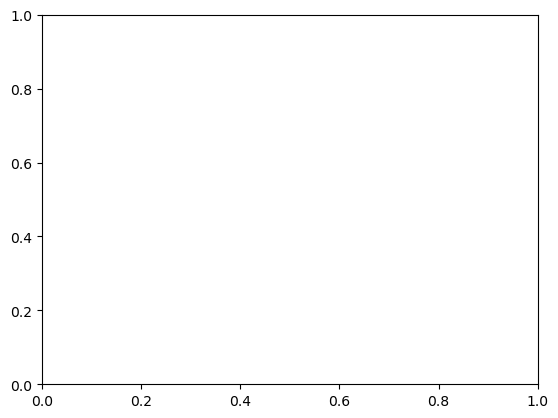

In [11]:
plt.figure()

plt.plot(k_range, inertia, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method')

plt.show()

ValueError: x and y must have same first dimension, but have shapes (9,) and (0,)

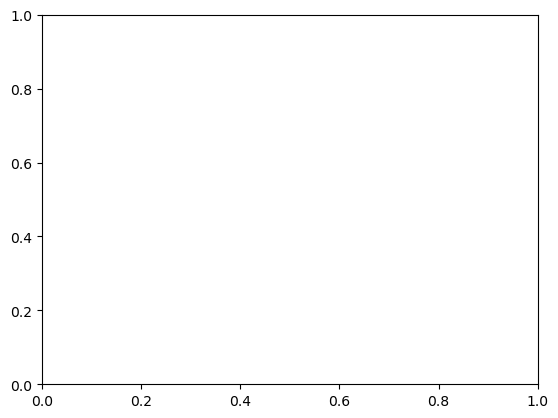

In [12]:
plt.figure()

plt.plot(k_range, silhouette, marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.show()

### Choosing the Optimal k

The elbow plot shows where the reduction in inertia begins to slow down, indicating diminishing returns from adding more clusters.

The silhouette score measures how well-separated clusters are.

By comparing both metrics, we select the value of k that balances compact clusters with good separation.

In [13]:
k_optimal = 3

kmeans_raw = KMeans(n_clusters=k_optimal, random_state=42)

labels_raw = kmeans_raw.fit_predict(scaled_df)

NameError: name 'scaled_df' is not defined

## Clustering on PCA-Reduced Data

In [14]:
kmeans_pca = KMeans(n_clusters=k_optimal, random_state=42)

labels_pca = kmeans_pca.fit_predict(pca_data)

NameError: name 'pca_data' is not defined

In [ ]:
silhouette_raw = silhouette_score(scaled_df, labels_raw)
silhouette_pca = silhouette_score(pca_data, labels_pca)

print("Silhouette score (original scaled data):", silhouette_raw)
print("Silhouette score (PCA reduced data):", silhouette_pca)

### PCA vs Raw Data

Comparing silhouette scores helps determine whether dimensionality reduction improves clustering performance.

If PCA produces a similar or higher silhouette score, it suggests that the reduced dataset preserves meaningful cluster structure while simplifying the data.

Even if the score slightly decreases, PCA can still be beneficial by reducing noise and improving interpretability.

In [15]:
pca_2 = PCA(n_components=2)

pca_2d = pca_2.fit_transform(scaled_df)

NameError: name 'scaled_df' is not defined

In [ ]:
plt.figure()

plt.scatter(pca_2d[:,0], pca_2d[:,1], c=labels_raw)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Clusters in PCA Space')

plt.show()

## Principal Component Interpretation

By examining the PCA loadings, we can understand which original variables contribute most to each principal component.

PC1 typically captures the largest variance in spending patterns, while PC2 captures the next most significant variation.

These components help visualize customers in a simplified space while preserving meaningful differences in purchasing behavior.

## Cluster Insights

The clustering results reveal distinct customer groups based on spending behavior.

Some clusters may represent customers who spend heavily on grocery-related items, while others may focus more on fresh products or specialty items.

These differences suggest potential customer segments such as:

- High-volume retailers purchasing large grocery and detergent quantities.
- Hospitality-focused buyers with higher fresh product spending.
- Smaller specialty buyers purchasing niche product categories.

## Conclusion

This analysis applied PCA and K-Means clustering to uncover natural customer segments within the wholesale dataset.

The workflow included data preparation, dimensionality reduction, cluster evaluation, and interpretation of results.

The findings demonstrate how unsupervised learning techniques can reveal hidden structure in business data and provide insights that support more informed decision-making.